## Exercise 1: Image Segmentation and Data Clustering

### Introduction
In this exercise, we apply three image segmentation methods - simple chessboard segmentation, K-Means clustering, and SLIC superpixels - to aerial images from the Potsdam dataset. Each method segments the data differently, ranging from fixed grids to data-driven clustering. The results are evaluated against provided ground truth labels to assess segmentation accuracy and performance.

**Note:** Your submission will be evaluated automatically, so it is essential to use the predefined parameter names for each task. To minimize computational load, your free-text answers are limited to **750** characters. You can verify this by clicking the `Validate` button in the toolbar above.

**Important:** As we are working with high-resolution image data, inefficient code can result in significantly longer execution times. It is strongly recommended to use vectorized operations instead of for-loops whenever possible. The autograding tool allows a maximum execution time of **10 minutes per cell**, so ensure your code runs well within this limit. With vectorized operations, all cells should execute within seconds.

**Data:** Within this docker image are only the tiles `5_10`, `5_11` and `5_12` available.


Execute the cell below to import all necessary libraries for this exercise.

In [107]:
# Required Libraries
import time

import numpy as np
import matplotlib.pyplot as plt

from skimage import io
from skimage.transform import rescale
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float
from sklearn.cluster import KMeans

# Custom paramters - do not change!
EXECUTE_GRADING = False
DOCKER_ENV = False
%matplotlib inline

### Task 1: Data Import and Analysis (11 Points)
In the field of image processing most commonly OpenCV is used to import and process image data. However, we use `skimage.io` to also handle multiband images like the RGBIR image. In the following section you have to write the code that reads and plots the data of tile `5_10`. 

**Result**: Use the variable names `img_rgb`, `img_ir`, `dsm`, `img_gt` as in the provided code. Ensure the correct shapes of the arrays `img_rgb` (6000x6000x3), `img_ir` (6000x6000), `dsm` (6000x6000) and `img_gt` (6000x6000x3). The required data type is `uint8`.

RGB: (6000, 6000, 3)
IR : (6000, 6000)
DSM: (6000, 6000)
GT : (6000, 6000, 3)


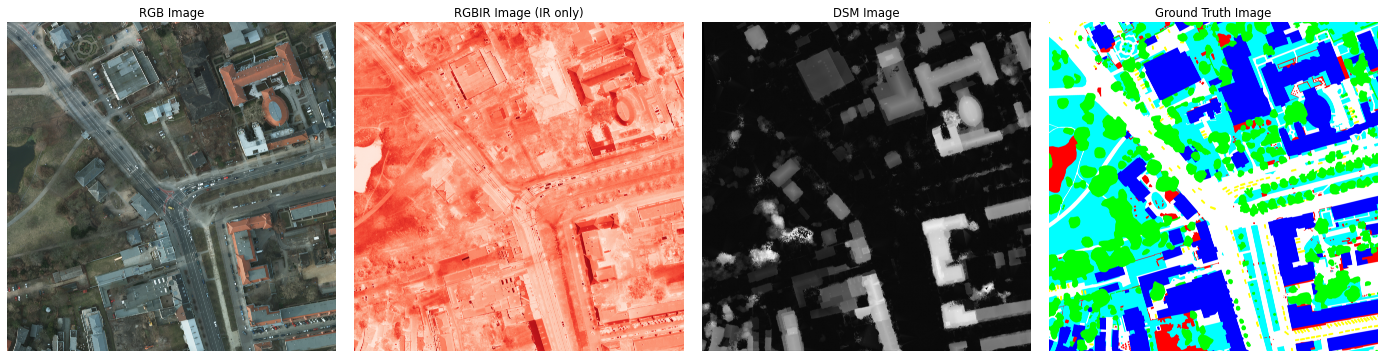

In [108]:
train_tile_name = "5_10"

if DOCKER_ENV:
    data_path = "/home/jovyan/data"
else:
    data_path = "../../../../__shared"

    
train_dsm_filename = f"{data_path}/1_DSM_normalisation/dsm_potsdam_0{train_tile_name}_normalized_lastools.jpg"
train_rgb_filename = f"{data_path}/2_Ortho_RGB/top_potsdam_{train_tile_name}_RGB.tif"
train_rgbir_filename = f"{data_path}/4_Ortho_RGBIR/top_potsdam_{train_tile_name}_RGBIR.tif"
train_gt_filename = f"{data_path}/5_Labels_all/top_potsdam_{train_tile_name}_label.tif"

# YOUR CODE HERE
# Tile name
train_tile_name = "5_10"

# These come directly from the Notebook (correct paths)
rgbir_path = f"{data_path}/4_Ortho_RGBIR/top_potsdam_{train_tile_name}_RGBIR.tif"
gt_path    = f"{data_path}/5_Labels_all/top_potsdam_{train_tile_name}_label.tif"
dsm_path   = f"{data_path}/1_DSM_normalisation/dsm_potsdam_0{train_tile_name}_normalized_lastools.jpg"

# --- Load images ---

# RGBIR image (4 channels)
img_rgbir = io.imread(rgbir_path)

# Split RGB and IR
img_rgb = img_rgbir[:, :, :3].astype(np.uint8)
img_ir  = img_rgbir[:, :, 3].astype(np.uint8)

# DSM
dsm = io.imread(dsm_path).astype(np.uint8)

# Ground Truth
img_gt = io.imread(gt_path).astype(np.uint8)

# --- Print shapes ---
print("RGB:", img_rgb.shape)
print("IR :", img_ir.shape)
print("DSM:", dsm.shape)
print("GT :", img_gt.shape)




## Do not change the code below - plotting only
fig, axs = plt.subplots(1, 4, figsize=(20, 5), dpi=70)
axs[0].imshow(img_rgb)
axs[0].set_title("RGB Image")
axs[0].axis("off")

axs[1].imshow(img_ir, cmap='Reds')  # Display only the RGB channels
axs[1].set_title("RGBIR Image (IR only)")
axs[1].axis("off")

axs[2].imshow(dsm, cmap='gray')
axs[2].set_title("DSM Image")
axs[2].axis("off")

axs[3].imshow(img_gt)
axs[3].set_title("Ground Truth Image")
axs[3].axis("off")

plt.tight_layout()
plt.show()


In [109]:
### Do not change the cell below - required for autograding


In [110]:
### Do not change the cell below - required for autograding


In [111]:
### Do not change the cell below - required for autograding


To reduce memory usage and power consumption, we downscale the images by a factor of `2`.

**Note:** Use `skimage.transform.rescale` function. Make sure to use the right interpolation order for the nDSM and ground truth. 

**Result:** Use the variable names `img_rgb_small`, `img_ir_small`, `dsm_small`, `img_gt_small`. Expected shapes are `(3000,3000,3)` or `(3000,3000)`.

In [112]:
# YOUR CODE HERE
from skimage.transform import rescale

scale_factor = 0.5   # 6000 → 3000

# RGB image (use anti-aliasing, preserve_range)
img_rgb_small = rescale(
    img_rgb, 
    scale_factor, 
    anti_aliasing=True,
    channel_axis=2,
    preserve_range=True
).astype(np.uint8)

# IR image (grayscale)
img_ir_small = rescale(
    img_ir,
    scale_factor,
    order=1,
    anti_aliasing=True,
    preserve_range=True
).astype(np.uint8)

# DSM image (height map → nearest-neighbor interpolation)
dsm_small = rescale(
    dsm,
    scale_factor,
    order=0,              # nearest-neighbor
    anti_aliasing=False,
    preserve_range=True
).astype(np.uint8)

# Ground truth labels (must NOT interpolate → order=0)
img_gt_small = rescale(
    img_gt,
    scale_factor,
    order=0,              # nearest-neighbor
    anti_aliasing=False,
    preserve_range=True,
    channel_axis=2
).astype(np.uint8)

# Print shapes for verification
print("RGB small:", img_rgb_small.shape)
print("IR small:", img_ir_small.shape)
print("DSM small:", dsm_small.shape)
print("GT small:", img_gt_small.shape)


RGB small: (3000, 3000, 3)
IR small: (3000, 3000)
DSM small: (3000, 3000)
GT small: (3000, 3000, 3)


In [113]:
### Do not change the cell below - required for autograding
#TODO: Abfangen FF bei falschem Shape


In [114]:
### Do not change the cell below - required for autograding


In [115]:
### Do not change the cell below - required for autograding


**1. Question:** 
In the context of remote sensing or pattern recognition, interpolation is not suitable for all types of input data, as it can distort the information content. Please list the types of input data in this exercise where interpolation would lead to distorted results, and briefly explain why.

**Note:** This consideration is also relevant to the dataset used in the previous task. If you haven’t already done so, make sure that interpolation was applied only to appropriate data types.

Interpolation is unsuitable for DSM and Ground Truth labels.
DSM contains real elevation values; interpolation changes these measurements and produces artificial heights, distorting geometric information.
Ground Truth labels are categorical class values; interpolation mixes colors and creates invalid classes, destroying the semantic meaning of the labels.

As an additional preprocessing step, we want to further reduce the data size of the ground truth image. To do this, and in accordance with the exercise instructions, we define a mapping function (`label_def`) that assigns class numbers (labels) to specific colors in the ground truth image (`img_gt`).
To switch between these two representations, complete the implementation of the methods rgb2index() and index2rgb().
This allows us to avoid storing a 3D color image and instead reduce it to a 2D label image, where each class is represented by a single integer.

**Note:** For this task only the usage of the numpy library (`np`) is allowed. It is not recommended to loop over the entire ground truth image using a for loop, as this will result in slow execution times. Instead, it is highly recommended to use clever indexing and functions like `.flatten()` and `.reshape()` to efficiently replace the corresponding values or vectors.

In [116]:
### Do not change the parameter definition `label_def``
label_def = np.array([[255, 255, 255], [255, 255, 0], [0, 0, 255], [0, 255, 255], [0, 255, 0], [255, 0, 0]])

def rgb2index(img_gt, colormap):
    """
    Converts RGB image (H x W x 3) to label image (H x W) using vectorized mapping.
    Parameters:
        img_gt (np.ndarray): RGB image (H, W, 3) with dtype uint8
        colormap (np.ndarray): Color map of shape (K, 3) with dtype uint8
    Returns:
        labels (np.ndarray): Label image of shape (H, W) with class indices
    """
    H, W, _ = img_gt.shape
    labels = np.zeros((H, W), dtype=np.uint32)
    for k, color in enumerate(colormap):
        # create a (H,W) mask where all three channels match this color
        mask = np.all(img_gt == color, axis=-1)
        labels[mask] = k
    return labels
    

def index2rgb(labels, colormap):
    """
    Converts a label index image (H x W) to an RGB image (H x W x 3) using the given colormap.
    Parameters:
        labels (np.ndarray): Label image of shape (H, W) with class indices
        colormap (np.ndarray): Color map of shape (K, 3) with dtype uint8
    Returns:
        img_gt (np.ndarray): RGB image (H, W, 3) with dtype uint8
    """
    # YOUR CODE HERE
    img_gt = colormap[labels]
    return img_gt
    

    
   

# Convert the ground truth image to label indices
labels_small = rgb2index(img_gt_small, label_def)

In [117]:
### Do not change the cell below - required for autograding


In [118]:
### Do not change the cell below - required for autograding


### Task 2: Segmentation Methods (22 Points)
In this task, we will implement and compare three fundamental image segmentation techniques: Chessboard segmentation, K-means clustering, and SLIC (Simple Linear Iterative Clustering) superpixels. Each method approaches the segmentation problem from a different perspective - ranging from simple grid-based partitioning to unsupervised clustering and perceptually-aware region growing.

#### 2.1 Chessboard Segmentation (4 Points) 

Complete the implementation of the simple and uninformed chessboard segmentation below. The segment size shall be calculated based on the number of segments. 

**Note:** `adjust_segments_to_fit_image()` is a helper function to ensure the size of the segments is an exact multiple of the image shape. We assume all images provided are square to reduce the complexity. Ensure the segment numbering starts beginning with `0` (zero-based).

**Result:** The return value is a `mask` with segments numbered row (left to right) before column (top to bottom). So the lowest value (0) is in the top left corner and the highest value in the botton right corner. Ensure the resulting mask is of type `int`.

In [119]:
def chessboard_segmentation(image, num_segments):
    """
    Segments a square image into approximately equal square patches,
    given a desired total number of segments.

    Parameters:
        image (ndarray): Input square image (H x W x C).
        num_segments (int): Total number of segments to divide the image into.

    Returns:
        mask (ndarray): Segmentation mask with labeled segments.
    """
    mask = None
    
    h, w = image.shape[:2]
    rows, cols, tile_h, tile_w, final_segments = adjust_segments_to_fit_image((h, w), num_segments)

    # YOUR CODE HERE
        # Create an empty mask
    mask = np.zeros((h, w), dtype=int)

    label = 0
    for r in range(rows):
        for c in range(cols):
            # assign label to the tile
            r_start = r * tile_h
            r_end   = (r + 1) * tile_h
            c_start = c * tile_w
            c_end   = (c + 1) * tile_w
            
            mask[r_start:r_end, c_start:c_end] = label
            label += 1


    print(f"Image shape: {image.shape}, Segments: {final_segments}, Rows: {rows}, Cols: {cols}, Tile size: ({tile_h}, {tile_w})")

    return mask, final_segments


### Do not change the code below - helper function
def adjust_segments_to_fit_image(image_shape, target_segments):
    """
    Find the closest square number of segments such that
    the segment grid fits exactly into the image dimensions.
    """
    h, w = image_shape
    root = int(np.sqrt(target_segments))
    # Please note: 20% of the root value as search limit is a empirical value and not proven mathematically
    search_limits = max(20, int(root * 0.2)) 

    # Looking for the candidate fitting the image size exactly
    candidates = []
    for delta in range(-search_limits, search_limits + 1, 1):
        segs = (root + delta) ** 2
        rows = int(np.sqrt(segs))
        cols = rows
        if rows == 0 or cols == 0:
            continue
        if h % rows == 0 and w % cols == 0:
            candidates.append((segs, rows, cols))

    if not candidates:
        raise ValueError("No perfect square segment grid found that fits the image size exactly.")

    # The candidate with the closest number of segments to the target is selected
    best = min(candidates, key=lambda x: abs(x[0] - target_segments))
    final_segments, rows, cols = best

    tile_h = h // rows
    tile_w = w // cols

    return rows, cols, tile_h, tile_w, final_segments

In [120]:
### Do not change the cell below - required for autograding


In [121]:
### Do not change the cell below - required for autograding


In [122]:
### Do not change the cell below - required for autograding


#### 2.2 KMeans Clustering (3 Points)

Complete the implementation of the `kmeans_segmentation_nchannel()` below. The method shall be able to process multispectral images with an arbitrary number of channels. 

**Note:** Use the `KMeans` method from the library `sklearn.cluster` to fulfill the required task. 

**Result:** Ensure the resulting mask is of type `int`. Ensure the segment numbering starts beginning with `0` (zero-based).


In [123]:

def kmeans_segmentation_nchannel(img_nchannel, k, max_iter):
    """
    Apply K-Means clustering segmentation on an N-channel image, optionally with spatial features.
    
    Parameters:
        img_nchannel (np.ndarray): Input image with shape (H, W, C) where C >= 1.
        k (int): Number of clusters.
        max_iter (int): Maximum iterations for KMeans.
    
    Returns:
        mask (np.ndarray): Segmentation label mask of shape (H, W).
    """
    # YOUR CODE HERE
    H, W, C = img_nchannel.shape
    
    # reshape to (H*W, C)
    X = img_nchannel.reshape(-1, C)
    
    # apply KMeans
    kmeans = KMeans(n_clusters=k, max_iter=max_iter, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # reshape labels back to (H, W)
    mask = labels.reshape(H, W).astype(int)   
    return mask
    


   


In [124]:
### Do not change the cell below - required for autograding


In [125]:
### Do not change the cell below - required for autograding


#### 2.3 SLIC superpixels segmentation (2 Points)

Complete the implementation of the `slic_segmentation()` below.

**Note:** Use the `slic` method from the library `skimage.segmentation` to fulfill the required task. 

**Result:** Ensure the resulting mask is of type `int`. Ensure the segment numbering starts beginning with `0` (zero-based).

In [126]:
def slic_segmentation(image, num_segments, compactness):
    
    segments = None

    # YOUR CODE HERE
    from skimage.segmentation import slic

    segments = slic(
        image,
        n_segments=num_segments,
        compactness=compactness,
        start_label=0
    ).astype(int)

    
    return segments

In [127]:
#### Do not change the cell below - required for autograding


#### 2.4 Testing (2 Points)

Complete the following cell to generate the segmentation masks using all three implemented methods. Use the predefined plots to check your implementation and begin tuning your parameters within a reasonable range. 

**Result:** Stick with the variable names `chess_mask`, `kmeans_mask`, `slic_mask`, otherwise the plots won`t workout.

Image shape: (3000, 3000, 3), Segments: 64, Rows: 8, Cols: 8, Tile size: (375, 375)


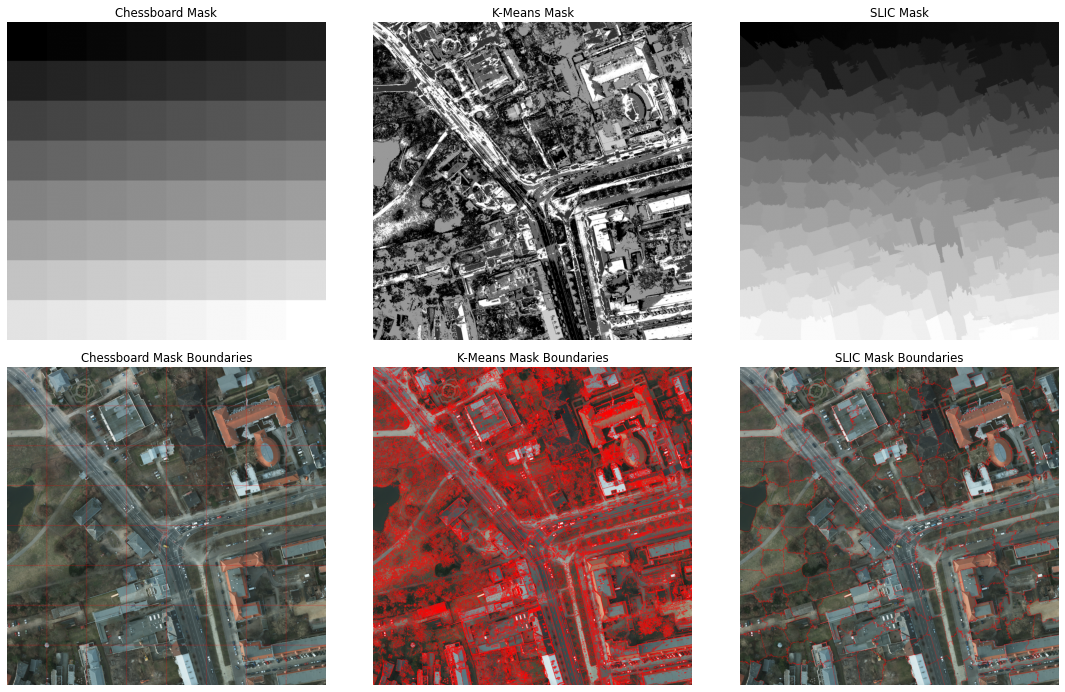

In [128]:
# YOUR CODE HERE
chess_mask, _ = chessboard_segmentation(img_rgb_small, 64)
kmeans_mask = kmeans_segmentation_nchannel(img_rgb_small, k=6, max_iter=100)
slic_mask = slic_segmentation(img_rgb_small, num_segments=200, compactness=20)

### Do not change the code below - plotting only
image = img_rgb_small
colormap = 'gray'
alpha = 0.5

# Plotting the masks and overlays
fig, axs = plt.subplots(2, 3, figsize=(16, 10), dpi=70)
axs = axs.flatten()

masks = [chess_mask, kmeans_mask, slic_mask]
titles = ['Chessboard Mask', 'K-Means Mask', 'SLIC Mask']

# Top row: grayscale masks
for i, (mask, title) in enumerate(zip(masks, titles)):
    axs[i].imshow(mask, cmap=colormap)
    axs[i].set_title(title)
    axs[i].axis('off')

# Bottom row: boundary overlays
for i, (mask, title) in enumerate(zip(masks, titles)):
    overlay = mark_boundaries(image, mask, color=(1, 0, 0))  # Red boundaries
    axs[i + 3].imshow(overlay)
    axs[i + 3].set_title(f'{title} Boundaries')
    axs[i + 3].axis('off')

plt.tight_layout()
plt.show()


#### 2.5 Feature and Accuracy calculation (11 Points)

Complete the implementation of the `mean_segments()` function to compute the average color of each segmented region in an image and generate a recolored output where each segment is filled with its mean RGB color. 

**Note:** For improved performance, the function uses `np.bincount()` to efficiently compute the sum and count of pixel values per segment without explicit loops over pixels.

**Result:** The expected return values are defined within the method description.

In [129]:
def mean_segments(orig_image, mask):
    """
    Fast, vectorized segment mean calculation. Assumes mask uses 0-based labels.

    Parameters:
        orig_image (np.ndarray): RGB image (H, W, 3)
        mask (np.ndarray): 2D label mask (H, W), 0-based integer labels
        
    Returns:
        image (np.ndarray): Recolored image with mean values per segment
        feature_vector (np.ndarray): (n_of_segments, 3) mean RGB values
    """
    image = None
    feature_vector = None
    
    # YOUR CODE HERE
        

    H, W, C = orig_image.shape
    mask_flat = mask.flatten()
    img_flat = orig_image.reshape(-1, C)

    
    n_segments = mask_flat.max() + 1

   
    sum_colors = np.vstack([
        np.bincount(mask_flat, weights=img_flat[:, c], minlength=n_segments)
        for c in range(C)
    ]).T   

    
    counts = np.bincount(mask_flat, minlength=n_segments).reshape(-1, 1)

   
    feature_vector = sum_colors / counts   

    
    image = feature_vector[mask_flat].reshape(H, W, C).astype(np.uint8)


    return image, feature_vector


In [130]:
#### Do not change the cell below - required for autograding


In [131]:
#### Do not change the cell below - required for autograding


Implement majority voting over image segments within the method `majority_vote_segments()` to assign each region a single class label based on the most frequent label within that segment.

**Note:** Use `np.bincount()` with a clever encoding of segment–class combinations to efficiently count label occurrences per segment. (optional)

**Result:** The expected return values are defined within the method description.

In [132]:
def majority_vote_segments(mask, labels_small):
    """
    Fast majority voting per segment using vectorized bincount.
    
    Parameters:
        mask (np.ndarray): (H, W) segment mask with 0-based integer segment IDs
        labels_small (np.ndarray): (H, W) predicted or ground truth labels
    
    Returns:
        voted_labels (np.ndarray): (H, W) label image after majority voting per segment
        accuracy (float): Pixel-wise accuracy of voted_labels vs. labels_small
    """
    voted_labels = None
    accuracy = None

    # YOUR CODE HERE
       
    mask_flat   = mask.flatten()
    labels_flat = labels_small.flatten()

    n_segments = mask_flat.max() + 1
    n_classes  = labels_flat.max() + 1

    # encode (segment, class) pairs uniquely
    encoded = mask_flat * n_classes + labels_flat

    # count how many pixels of each class are in each segment
    counts = np.bincount(encoded, minlength=n_segments * n_classes)
    counts = counts.reshape(n_segments, n_classes)

    # majority class for each segment
    majority = counts.argmax(axis=1)

    # map majority class back to pixel level
    voted_labels = majority[mask_flat].reshape(mask.shape)

    # compute pixel-wise accuracy
    accuracy = (voted_labels == labels_small).mean()


    return voted_labels, accuracy

In [133]:
### Do not change the cell below - required for autograding



In [134]:
#### Do not change the cell below - required for autograding


Within this cell, implement the full process - from generating a segmentation mask to obtaining the feature images and accuracy metrics - and benchmark the results. Use the predefined functions for all three segmentation methods, including mask generation, feature image creation, label image processing, and accuracy evaluation.

**Note:** Use `time.time()` to measure and analyze the execution time of each segmentation method - segmentation only!

**Result:** Tune the parameters of each method to find an optimal balance between execution time, accuracy, and data reduction. Submit your notebook using the best parameter set identified. Make sure to use the predefined parameter names to ensure compatibility with the autograding system and plotting functionality.


Image shape: (3000, 3000, 3), Segments: 64, Rows: 8, Cols: 8, Tile size: (375, 375)
Chessboard Segmentation - Time: 0.38 seconds
Chessboard Segmentation - Accuracy: 0.47
KMeans Segmentation - Time: 41.69 seconds
KMeans Segmentation - Accuracy: 0.49
SLIC Segmentation - Time: 6.11 seconds
SLIC Segmentation - Accuracy: 0.61


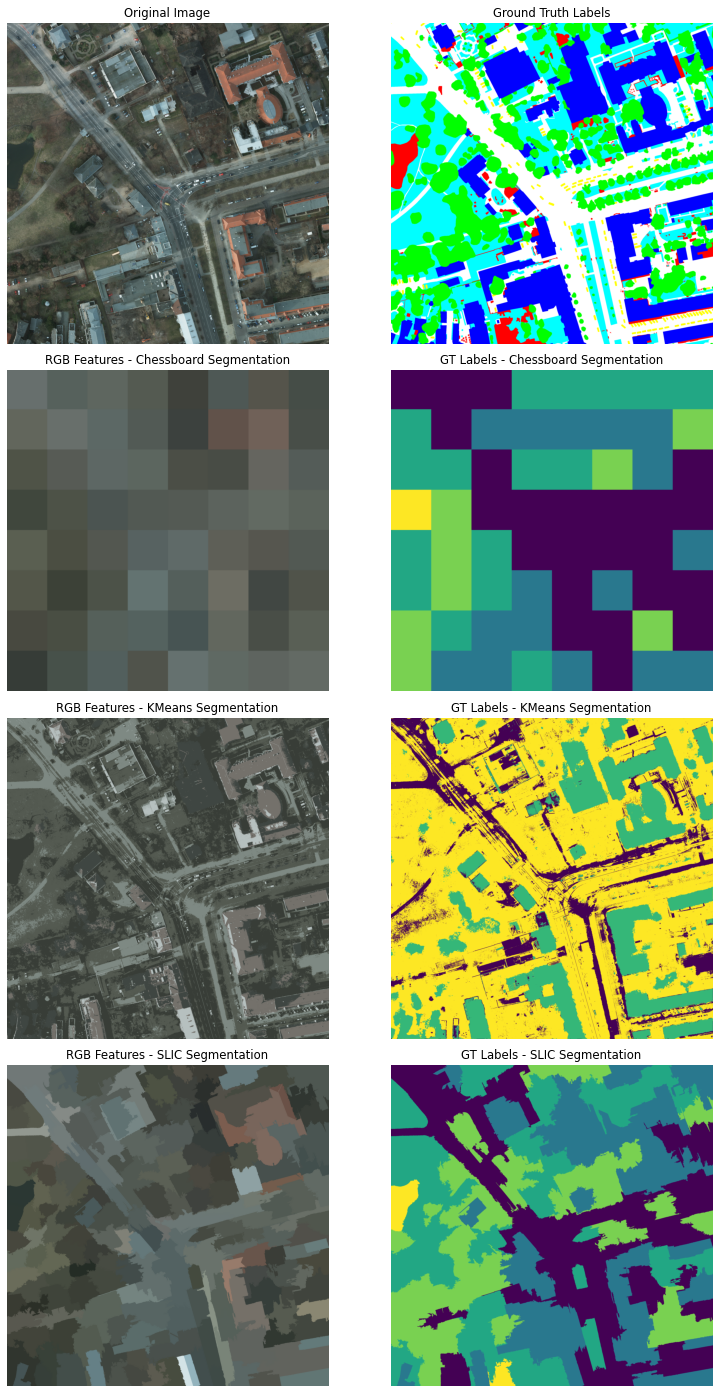

In [135]:
#Create a multichannel image for KMeans
multichannel_img = np.dstack([img_rgb_small, img_ir_small, dsm_small])

# variable definitions
features_image_chess = None
labels_image_chess = None
feature_vector_kmeans = None
labels_image_kmeans = None
features_image_slic = None
labels_image_slic = None

# Chessboard segmentation
time_start = 0
time_end = 0
accuracy_chess = 0

# YOUR CODE HERE
# Chessboard segmentation
time_start = time.time()

# 1. Segment
chess_mask, _ = chessboard_segmentation(img_rgb_small, 64)

# 2. Feature image (mean color)
features_image_chess, _ = mean_segments(img_rgb_small, chess_mask)

# 3. Majority vote accuracy
labels_image_chess, accuracy_chess = majority_vote_segments(chess_mask, labels_small)

time_end = time.time()


print(f"Chessboard Segmentation - Time: {time_end - time_start:.2f} seconds")
print(f"Chessboard Segmentation - Accuracy: {accuracy_chess:.2f}")

# KMeans segmentation
time_start = 0
time_end = 0
accuracy_kmeans = 0

# YOUR CODE HERE
# KMeans segmentation
time_start = time.time()

# 1. Segment
kmeans_mask = kmeans_segmentation_nchannel(multichannel_img, k=6, max_iter=100)

# 2. Feature image (mean color)
features_image_kmeans, _ = mean_segments(img_rgb_small, kmeans_mask)

# 3. Majority vote accuracy
labels_image_kmeans, accuracy_kmeans = majority_vote_segments(kmeans_mask, labels_small)

time_end = time.time()


print(f"KMeans Segmentation - Time: {time_end - time_start:.2f} seconds")
print(f"KMeans Segmentation - Accuracy: {accuracy_kmeans:.2f}")

# SLIC segmentation
time_start = 0
time_end = 0
accuracy_slic = 0

# YOUR CODE HERE
# SLIC segmentation
time_start = time.time()

# 1. Segment
slic_mask = slic_segmentation(img_rgb_small, num_segments=250, compactness=10)

# 2. Feature image (mean color)
features_image_slic, _ = mean_segments(img_rgb_small, slic_mask)

# 3. Majority vote accuracy
labels_image_slic, accuracy_slic = majority_vote_segments(slic_mask, labels_small)

time_end = time.time()


print(f"SLIC Segmentation - Time: {time_end - time_start:.2f} seconds")
print(f"SLIC Segmentation - Accuracy: {accuracy_slic:.2f}")


### Do not change the cell below - plotting only
fig, axs = plt.subplots(4, 2, figsize=(12, 20), dpi=70)

axs[0,0].imshow(img_rgb_small)
axs[0,0].set_title("Original Image")
axs[0,0].axis("off")

axs[0,1].imshow(img_gt_small)
axs[0,1].set_title("Ground Truth Labels")
axs[0,1].axis("off")

axs[1,0].imshow(features_image_chess)
axs[1,0].set_title("RGB Features - Chessboard Segmentation")
axs[1,0].axis("off")

axs[1,1].imshow(labels_image_chess)
axs[1,1].set_title("GT Labels - Chessboard Segmentation")
axs[1,1].axis("off")

axs[2,0].imshow(features_image_kmeans)
axs[2,0].set_title("RGB Features - KMeans Segmentation")
axs[2,0].axis("off")

axs[2,1].imshow(labels_image_kmeans)
axs[2,1].set_title("GT Labels - KMeans Segmentation")
axs[2,1].axis("off")

axs[3,0].imshow(features_image_slic)
axs[3,0].set_title("RGB Features - SLIC Segmentation")
axs[3,0].axis("off")

axs[3,1].imshow(labels_image_slic)
axs[3,1].set_title("GT Labels - SLIC Segmentation")
axs[3,1].axis("off")

plt.tight_layout()
plt.show()

**2. Question:** 
Based on the evaluation metrics defined above, determine which method serves as the best preprocessing step for subsequent semantic segmentation. Justify your choice by considering the trade-offs between execution time, accuracy, and data reduction

YOUR ANSWER HERE

### Task 3: Review on Segmentation - Questions (8 Points)
This part is designed to reinforce your understanding and prepare you for the exam.

**3. Question:** 
What are the main differences between k-means clustering and SLIC?

K-means performs clustering only in the feature space (e.g., RGB, multispectral values). Spatial information is not considered, so clusters may appear scattered or noisy.

SLIC (Simple Linear Iterative Clustering) incorporates both spectral features and spatial coordinates (x, y), creating spatially coherent superpixels.

K-means produces irregular, non-contiguous clusters, while SLIC generates compact, smooth, and locally consistent regions.

SLIC is often faster because it restricts the search to a small local neighborhood; K-means operates globally.

K-means output is a standard cluster map, while SLIC output is a superpixel segmentation with clear boundaries.

**4. Question:**
What is the difference between segmentation and semantic segmentation?

Segmentation (unsupervised or low-level segmentation)
Divides an image into regions of similar appearance (color, intensity, texture).
The regions do not have semantic meaning or class labels.
Examples: k-means clustering, SLIC, superpixels, thresholding.

Semantic segmentation (high-level, supervised)
Assigns a meaningful class label to every pixel, such as building, road, vegetation, water.
Requires training data with ground-truth labels and usually machine learning or deep learning models.

**5. Question:**
Why is unsupervised segmentation often used as a pre-processing step for other tasks in pattern recognition?

Unsupervised segmentation is useful because:

It reduces the number of elements (from millions of pixels to a few thousand segments), making later algorithms faster.

Segments group pixels with similar characteristics, improving the stability of feature extraction.

It reduces noise and produces smoother representations of objects.

It helps capture object boundaries, enabling better downstream classification.

In cases with limited labeled data, segmentation provides a helpful intermediate structure for later supervised tasks.

**6. Question:**
Do you see other possibilities to calculate the feature vector of a segment (instead of averaging)? Are there advantages of these possibilities?

Yes. Instead of averaging, segments can be represented by more informative features. Median values are more robust to outliers. Color or texture histograms capture the full distribution of pixel values rather than a single summary. Standard deviation or variance describe texture strength inside the segment. Texture descriptors (e.g., LBP or GLCM) encode structural patterns. Deep learned features (CNN embeddings) provide high-level semantic information. These alternatives often improve classification accuracy and robustness.

**7. Question:**
How could you employ k-means directly for semantic segmentation?

K-means can be used for semantic segmentation by clustering pixels based on color, intensity, or multi-channel features (e.g., RGB, IR, DSM). Each pixel is treated as a feature vector, and k-means assigns it to one of k clusters. After clustering, each cluster is interpreted as a semantic class. To make the result more meaningful, spatial features (pixel coordinates) can be added, or post-processing (e.g., majority voting with ground truth) can map clusters to actual semantic labels.

In [136]:
import nbformat
import re

def validate_nbgrader_cells_by_id(notebook_path, grade_id_pattern=r"E1-A\d+", char_threshold=750):
    nb = nbformat.read(open(notebook_path, encoding='utf-8'), as_version=4)
    pattern = re.compile(grade_id_pattern)
    matched_any = False

    for cell in nb.cells:
        if cell.cell_type != "markdown":
            continue

        nbgrader_meta = cell.metadata.get("nbgrader", {})
        grade_id = nbgrader_meta.get("grade_id")

        if  not grade_id:
            continue

        if pattern.fullmatch(grade_id):
            matched_any = True
            num_letters = sum(c.isalpha() for c in cell['source'])

            print(f"Cell '{grade_id}' has {num_letters} alphabetic characters.")
            if num_letters > char_threshold:
                raise AssertionError(
                    f"Cell with nbgrader.grade_id '{grade_id}' exceeds letter count: {num_letters} > {char_threshold}"
                )

    if not matched_any:
        print("No nbgrader cells matched the pattern.")
    else:
        print("All nbgrader markdown cells are within the character limit.")

# Validate the notebook
validate_nbgrader_cells_by_id("Task.ipynb", grade_id_pattern=r"E1\-A\d+", char_threshold=750)

Cell 'E1-A1' has 305 alphabetic characters.
Cell 'E1-A2' has 14 alphabetic characters.
Cell 'E1-A3' has 548 alphabetic characters.
Cell 'E1-A4' has 407 alphabetic characters.
Cell 'E1-A5' has 447 alphabetic characters.
Cell 'E1-A6' has 442 alphabetic characters.
Cell 'E1-A7' has 385 alphabetic characters.
All nbgrader markdown cells are within the character limit.


In [137]:
## This command is required due to a current bug in the auto-correction tool used - Do not change the cell content at all ##
!rm -r .ipynb_checkpoints 